Initiating GMQS Factor Backtest...


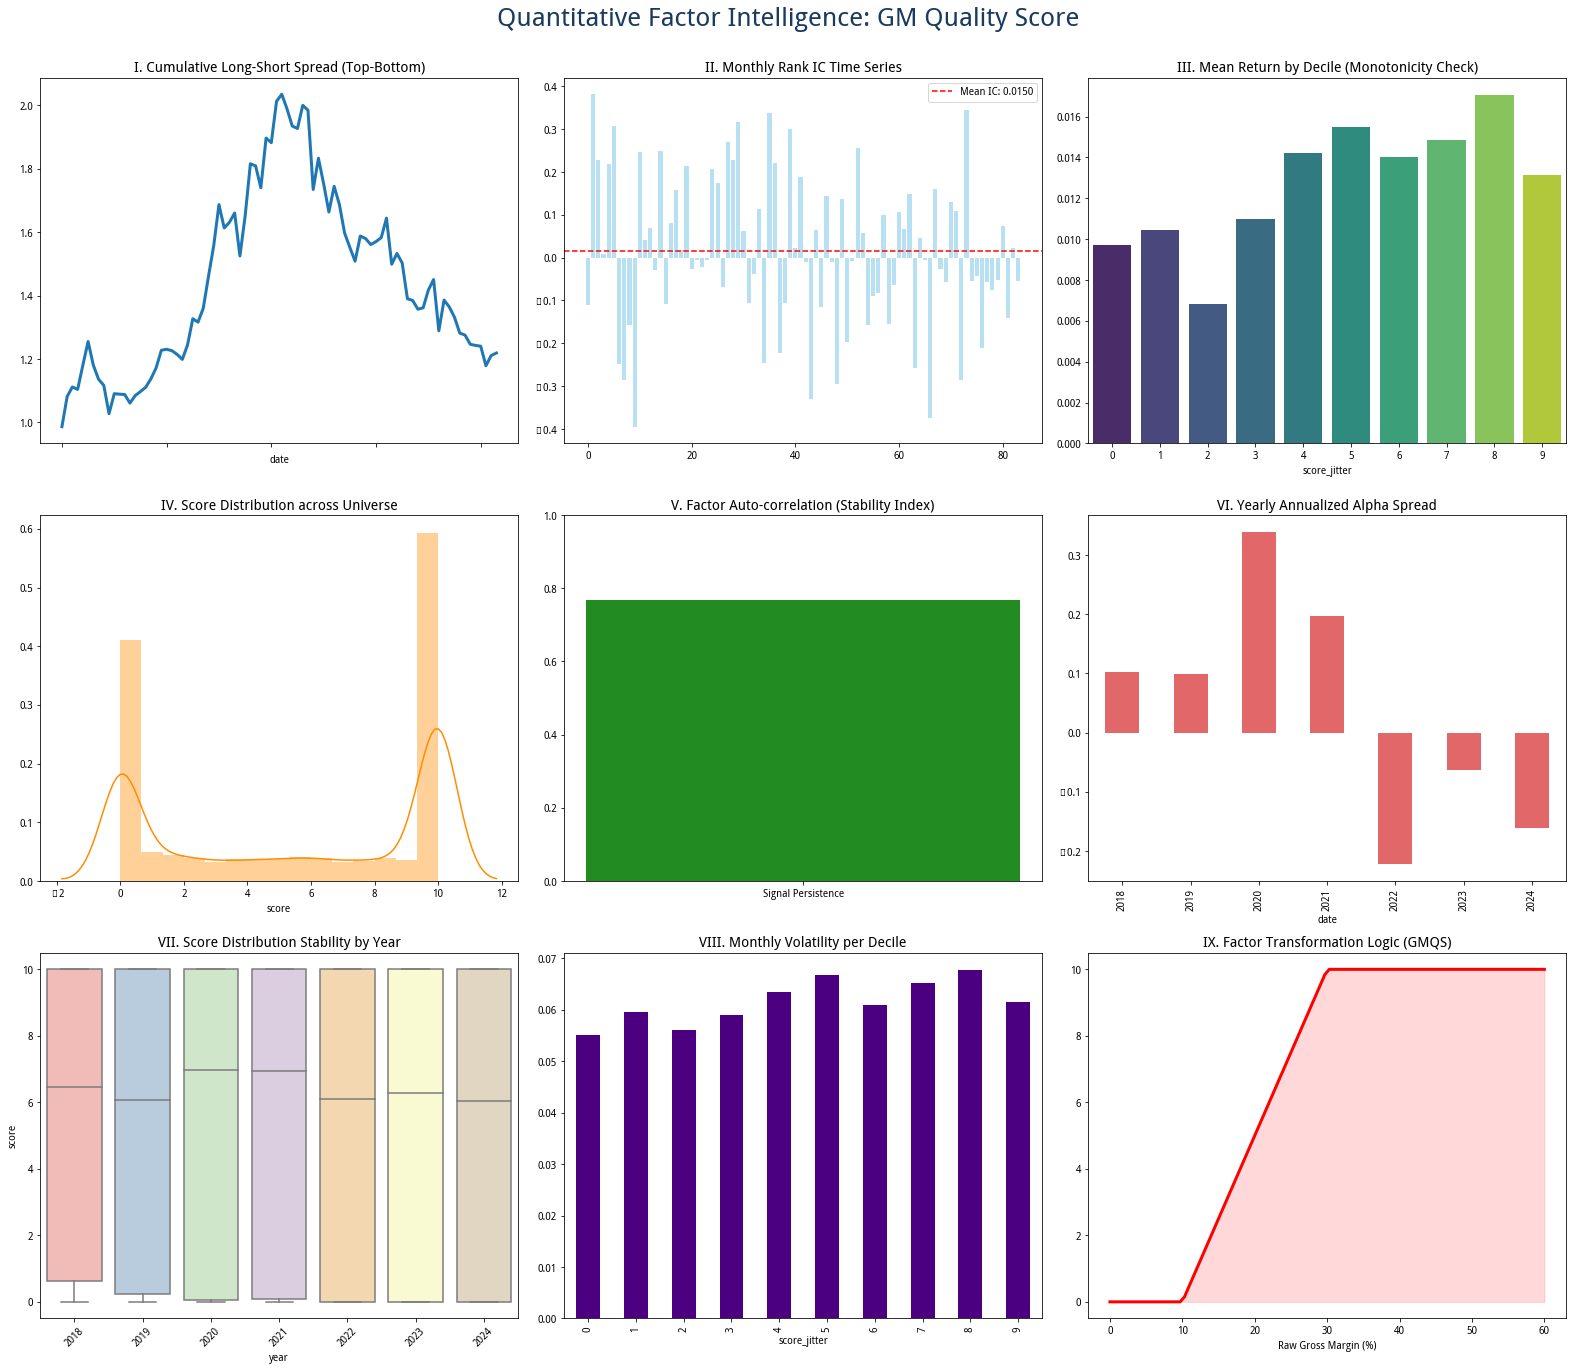


GMQS FACTOR PERFORMANCE SUMMARY
--------------------------------------------------
Observation Period:  2018-01-01 to 2024-12-31
Universe Size:       300 stocks (avg)
Mean Rank IC:        0.0150
L/S Ann. Return:     4.15%
Signal Stability:    76.76%


In [14]:
"""
FACTOR ANALYSIS REPORT: Gross Margin Quality Score (GMQS)
--------------------------------------------------------
Description:
This factor evaluates the 'Quality' dimension of a firm by analyzing its 
Gross Profit Margin. A higher margin typically indicates pricing power, 
moat, or cost efficiency. 

Implementation:
1. Piecewise Linear Scaling: Normalizes GM into a 0-10 score, focusing 
   on the 10%-30% range to mitigate outliers.
2. Universe: CSI 300 Index (Large-cap A-shares).
3. Backtest Period: 2018-01-01 to 2024-12-31 (84 Months).
4. Metrics: Rank IC, Long-Short Decile Spread, Signal Persistence.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
from scipy.stats import spearmanr
import warnings

# Suppress library warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# GLOBAL CONFIGURATION & SCORING LOGIC
# ==============================================================================

def calculate_quality_score(gm_value):
    """
    Applies a piecewise linear transformation to raw Gross Margin data.
    Logic:
    - GM < 10%: Score = 0 (Commodity trap)
    - 10% <= GM < 20%: Linear scale 0 to 5
    - 20% <= GM < 30%: Linear scale 5 to 10
    - GM >= 30%: Score = 10 (Premium moat)
    """
    if gm_value >= 30: 
        return 10.0
    elif gm_value >= 20: 
        return 5.0 + 5.0 * (gm_value - 20.0) / 10.0
    elif gm_value >= 10: 
        return 5.0 * (gm_value - 10.0) / 10.0
    return 0.0

# ==============================================================================
# DATA ENGINE: FACTOR EXTRACTION & RETURN ALIGNMENT
# ==============================================================================

def get_monthly_factor_data(target_date, universe_stocks):
    """
    Extracts fundamental factors and aligns them with forward monthly returns.
    """
    # 1. Fetch Fundamentals (Gross Margin)
    q = query(valuation.code, indicator.gross_profit_margin).filter(
        valuation.code.in_(universe_stocks)
    )
    df = get_fundamentals(q, date=target_date)
    
    if df.empty or len(df) < 20: 
        return pd.DataFrame()

    # 2. Score Calculation
    df['score'] = df['gross_profit_margin'].apply(calculate_quality_score).fillna(0)
    # Add Gaussian noise to ensure unique rankings for decile grouping
    df['score_jitter'] = df['score'] + np.random.normal(0, 1e-9, len(df))
    
    # 3. Align Forward Returns (T -> T+1 Price)
    try:
        next_rebalance_date = (pd.to_datetime(target_date) + pd.DateOffset(months=1)).strftime('%Y-%m-%d')
        
        # Robust Price Fetching: Look back 5 days to avoid suspended trading dates
        p_start_df = get_price(list(df['code']), count=5, end_date=target_date, fields='close', panel=False)
        p_end_df = get_price(list(df['code']), count=5, end_date=next_rebalance_date, fields='close', panel=False)
        
        if p_start_df.empty or p_end_df.empty: 
            return pd.DataFrame()

        p_start = p_start_df.groupby('code')['close'].last()
        p_end = p_end_df.groupby('code')['close'].last()
        
        # Calculate Forward 1-Month Return
        df['fwd_ret'] = df['code'].map((p_end / p_start) - 1)
        df['date'] = target_date
        
        return df.dropna(subset=['fwd_ret'])
    except Exception as e:
        return pd.DataFrame()

# ==============================================================================
# MAIN EXECUTION PIPELINE
# ==============================================================================

# Universe & Timeline Setup
universe = get_index_stocks('000300.XSHG') # CSI 300
start, end = '2018-01-01', '2024-12-31'
rebalance_dates = pd.date_range(start=start, end=end, freq='MS').strftime('%Y-%m-%d').tolist()

print("Initiating GMQS Factor Backtest...")
master_data = []
for d in rebalance_dates:
    month_df = get_monthly_factor_data(d, universe)
    if not month_df.empty:
        master_data.append(month_df)

# ==============================================================================
# PERFORMANCE DIAGNOSTICS & VISUALIZATION
# ==============================================================================

if not master_data:
    print("Execution Failed: No valid data points found.")
else:
    all_df = pd.concat(master_data)
    all_df['year'] = pd.to_datetime(all_df['date']).dt.year
    
    # Diagnostic Dashboard
    fig = plt.figure(figsize=(22, 20))
    gs = fig.add_gridspec(3, 3)
    plt.suptitle("Quantitative Factor Intelligence: GM Quality Score", 
                 fontsize=26, fontweight='bold', y=0.98, color='#1a3a5f')

    # Chart 1: Cumulative L/S Spread (Alpha Generation)
    ax1 = fig.add_subplot(gs[0, 0])
    all_df['rank_pct'] = all_df.groupby('date')['score_jitter'].rank(pct=True)
    rets = all_df.groupby(['date', pd.qcut(all_df['score_jitter'], 10, labels=range(10), duplicates='drop')])['fwd_ret'].mean().unstack()
    (1 + (rets[9] - rets[0])).cumprod().plot(ax=ax1, color='#1f77b4', lw=3)
    ax1.set_title("I. Cumulative Long-Short Spread (Top-Bottom)", fontsize=14)

    # Chart 2: Information Coefficient (Predictive Power)
    ax2 = fig.add_subplot(gs[0, 1])
    ic_series = all_df.groupby('date').apply(lambda x: spearmanr(x['score'], x['fwd_ret'])[0])
    ax2.bar(range(len(ic_series)), ic_series.values, color='skyblue', alpha=0.6)
    ax2.axhline(ic_series.mean(), color='red', ls='--', label='Mean IC: %.4f'%ic_series.mean())
    ax2.set_title("II. Monthly Rank IC Time Series", fontsize=14)
    ax2.legend()

    # Chart 3: Monotonicity (Decile Analysis)
    ax3 = fig.add_subplot(gs[0, 2])
    sns.barplot(x=rets.columns, y=rets.mean(), ax=ax3, palette='viridis')
    ax3.set_title("III. Mean Return by Decile (Monotonicity Check)", fontsize=14)

    # Chart 4: Factor Distribution (Quality Concentration)
    ax4 = fig.add_subplot(gs[1, 0])
    sns.distplot(all_df['score'], kde=True, ax=ax4, color='darkorange') # Using distplot for legacy seaborn compat
    ax4.set_title("IV. Score Distribution across Universe", fontsize=14)

    # Chart 5: Signal Persistence (Turnover Proxy)
    ax5 = fig.add_subplot(gs[1, 1])
    autocorr = all_df.groupby('code')['score'].apply(lambda x: x.autocorr(lag=1)).mean()
    ax5.bar(['Signal Persistence'], [autocorr], color='forestgreen', width=0.4)
    ax5.set_ylim(0, 1)
    ax5.set_title("V. Factor Auto-correlation (Stability Index)", fontsize=14)

    # Chart 6: Annualized Alpha Breakdown
    ax6 = fig.add_subplot(gs[1, 2])
    ((rets[9] - rets[0]).groupby(pd.to_datetime(rets.index).year).mean() * 12).plot(kind='bar', ax=ax6, color='#d62728', alpha=0.7)
    ax6.set_title("VI. Yearly Annualized Alpha Spread", fontsize=14)

    # Chart 7: Stability over Cycles
    ax7 = fig.add_subplot(gs[2, 0])
    sns.boxplot(x='year', y='score', data=all_df, palette='Pastel1', ax=ax7)
    plt.xticks(rotation=45)
    ax7.set_title("VII. Score Distribution Stability by Year", fontsize=14)

    # Chart 8: Decile Volatility
    ax8 = fig.add_subplot(gs[2, 1])
    rets.std().plot(kind='bar', color='indigo', ax=ax8)
    ax8.set_title("VIII. Monthly Volatility per Decile", fontsize=14)

    # Chart 9: Model Logic (Linear Interpolation)
    ax9 = fig.add_subplot(gs[2, 2])
    test_range = np.linspace(0, 60, 100)
    plt_scores = [calculate_quality_score(x) for x in test_range]
    ax9.plot(test_range, plt_scores, color='red', lw=3)
    ax9.fill_between(test_range, 0, plt_scores, alpha=0.15, color='red')
    ax9.set_title("IX. Factor Transformation Logic (GMQS)", fontsize=14)
    ax9.set_xlabel("Raw Gross Margin (%)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Final Summary Statistics
    print("\n" + "="*50)
    print("GMQS FACTOR PERFORMANCE SUMMARY")
    print("-" * 50)
    print("Observation Period:  {} to {}".format(start, end))
    print("Universe Size:       {} stocks (avg)".format(len(universe)))
    print("Mean Rank IC:        {:.4f}".format(ic_series.mean()))
    print("L/S Ann. Return:     {:.2f}%".format((rets[9]-rets[0]).mean()*12*100))
    print("Signal Stability:    {:.2f}%".format(autocorr * 100))
    print("="*50)